<a href="https://colab.research.google.com/github/YoussefZaki06/Computer-Vision-Intel-Image-Classification/blob/main/Computer_Vision_%E2%80%94_Intel_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision — Intel Image Classification

## Project Introduction
This project builds an image classification system that categorizes natural scene photographs into 6 classes: buildings, forest, glacier, mountain, sea, and street. Two approaches are implemented and compared: a Convolutional Neural Network (CNN) trained from scratch, and a transfer learning model built on a pretrained network.

## Business / Real-World Problem
Automated scene classification has real applications in satellite/aerial imagery organization, travel and stock photo platforms (auto-tagging uploaded images by scene type), geographic and environmental monitoring (tracking land use or glacier/forest coverage over time from photo data), and content moderation or recommendation systems that rely on understanding what an image actually depicts. Manually tagging large photo datasets by scene type is slow and inconsistent — a trained model can do this instantly and at scale.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from PIL import Image

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

## 1. Dataset Understanding


In [3]:
data_dir = '/content/drive/MyDrive/DataSets/intel-image-classification/seg_train'
print(os.listdir(data_dir))

['buildings', 'forest', 'mountain', 'sea', 'glacier', 'street']


In [4]:
for class_name in sorted(os.listdir(data_dir)):
    class_path = os.path.join(data_dir, class_name)
    n_images = len(os.listdir(class_path))
    print(f"{class_name}: {n_images} images")

buildings: 2191 images
forest: 2271 images
glacier: 2404 images
mountain: 2512 images
sea: 2274 images
street: 2382 images


In [5]:

# check dimensions + mode (RGB vs grayscale) on a sample, and scan for corrupted files
sizes = []
modes = []
corrupted = []

for class_name in sorted(os.listdir(data_dir)):
    class_path = os.path.join(data_dir, class_name)
    for fname in os.listdir(class_path)[:100]:  # sample 100 per class for speed
        fpath = os.path.join(class_path, fname)
        try:
            img = Image.open(fpath)
            sizes.append(img.size)
            modes.append(img.mode)
        except Exception as e:
            corrupted.append(fpath)

print("Unique sizes found (sample):", set(sizes))
print("Unique modes found:", set(modes))
print("Corrupted files found:", len(corrupted))

Unique sizes found (sample): {(150, 76), (150, 150)}
Unique modes found: {'RGB'}
Corrupted files found: 0


In [6]:
# full corrupted-file scan across ALL images (worth doing properly, not just sampled)
corrupted_full = []
for class_name in sorted(os.listdir(data_dir)):
    class_path = os.path.join(data_dir, class_name)
    for fname in os.listdir(class_path):
        fpath = os.path.join(class_path, fname)
        try:
            img = Image.open(fpath)
            img.verify()
        except Exception:
            corrupted_full.append(fpath)

print(f"Total corrupted images: {len(corrupted_full)}")

Total corrupted images: 0


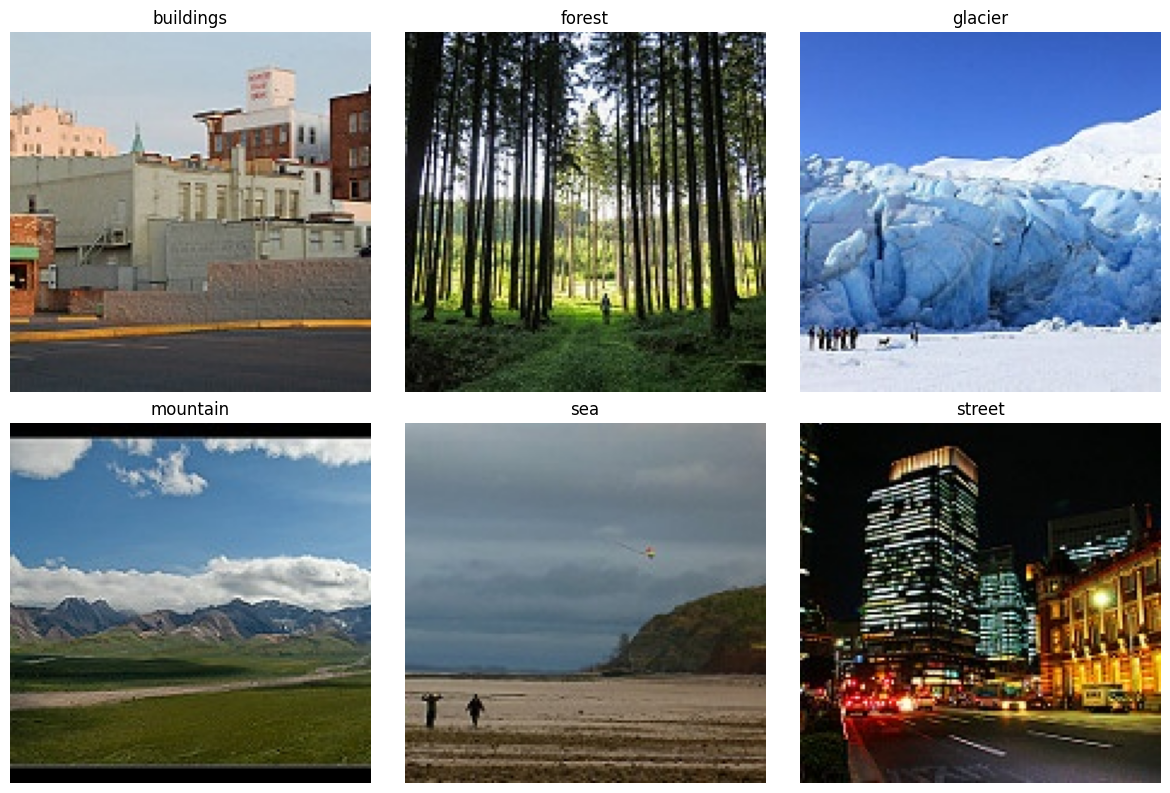

In [7]:
# sample grid: one image per class
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, class_name in enumerate(sorted(os.listdir(data_dir))):
    class_path = os.path.join(data_dir, class_name)
    sample_img = os.listdir(class_path)[0]
    img = Image.open(os.path.join(class_path, sample_img))
    axes[i].imshow(img)
    axes[i].set_title(class_name)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

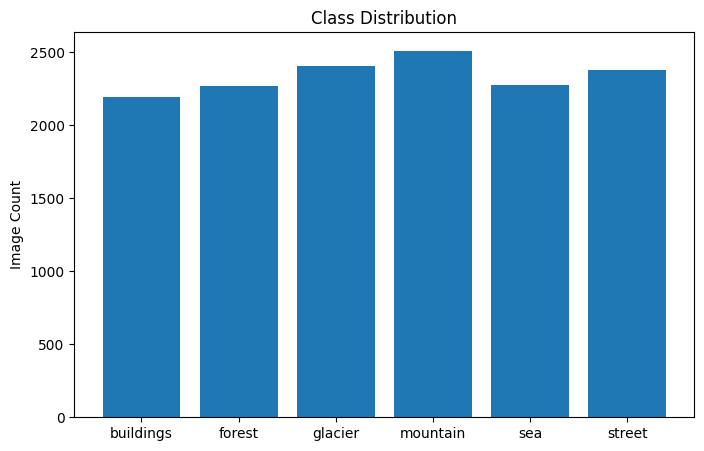

In [8]:
# class balance check
counts = {}
for class_name in sorted(os.listdir(data_dir)):
    counts[class_name] = len(os.listdir(os.path.join(data_dir, class_name)))

plt.figure(figsize=(8, 5))
plt.bar(counts.keys(), counts.values())
plt.title('Class Distribution')
plt.ylabel('Image Count')
plt.show()

**Observation:** Class counts range from 2191 (buildings) to 2512 (mountain)  roughly balanced, no class dominates or is severely underrepresented, so no special class weighting is needed for training.

## 2. Image EDA


In [9]:
# pixel value inspection - are they 0-255 or already normalized?
sample_path = os.path.join(data_dir, 'forest', os.listdir(os.path.join(data_dir, 'forest'))[0])
sample_img = np.array(Image.open(sample_path))
print("Pixel value range:", sample_img.min(), "-", sample_img.max())
print("Shape:", sample_img.shape)

Pixel value range: 0 - 255
Shape: (150, 150, 3)


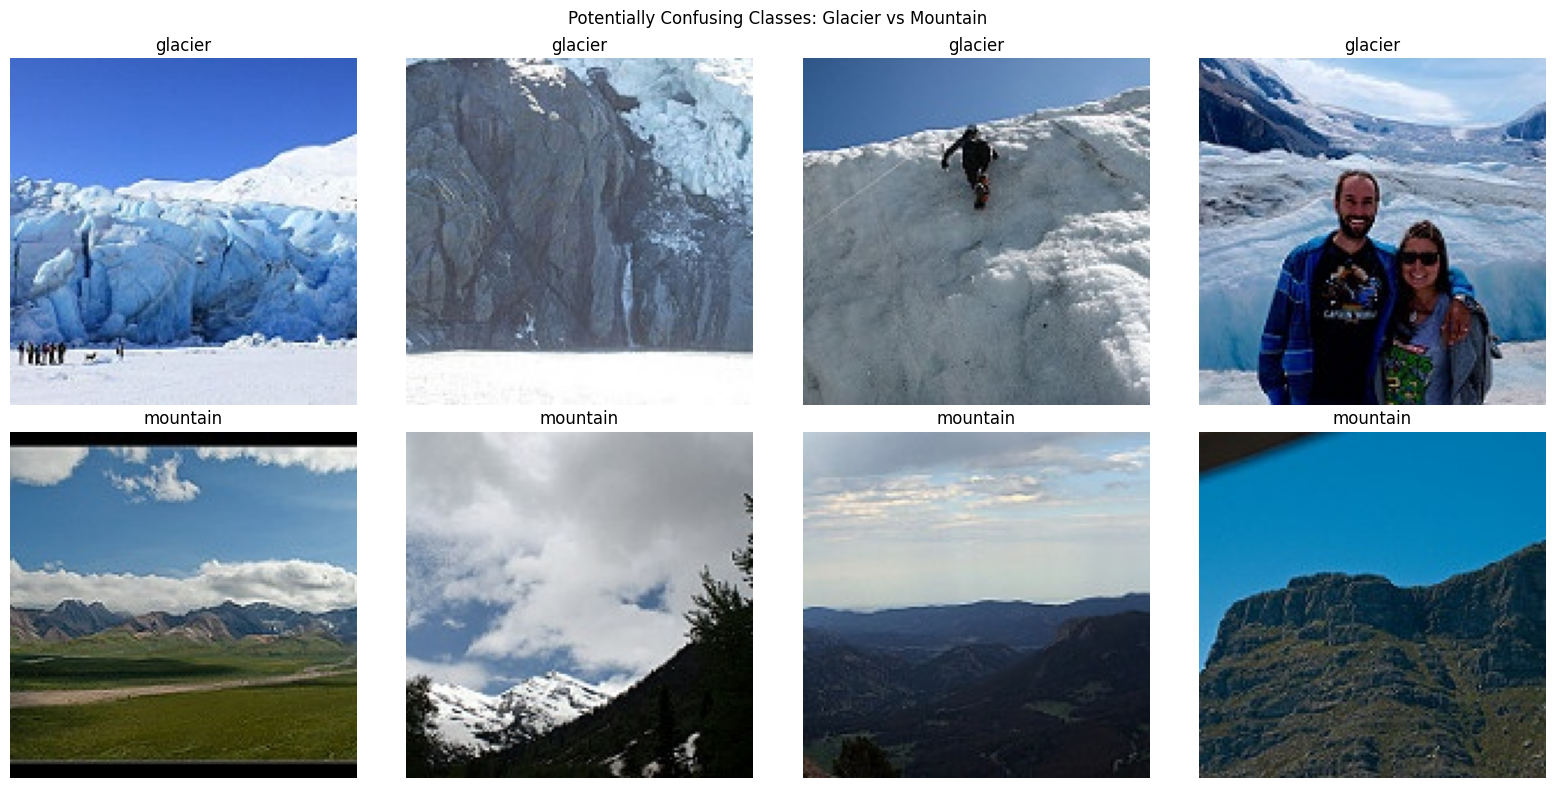

In [10]:
# visually similar/confusing classes side by side
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, cls in enumerate(['glacier', 'mountain']):
    class_path = os.path.join(data_dir, cls)
    imgs = os.listdir(class_path)[:4]
    for j, fname in enumerate(imgs):
        img = Image.open(os.path.join(class_path, fname))
        axes[i][j].imshow(img)
        axes[i][j].set_title(cls)
        axes[i][j].axis('off')

plt.suptitle('Potentially Confusing Classes: Glacier vs Mountain')
plt.tight_layout()
plt.show()

**"Glacier and mountain images share similar color palettes (blue/white/gray tones) and rocky/snowy textures, which may cause classification confusion"**

## 3. Preprocessing

## 4. Data Splitting

In [11]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [12]:
test_dir = '/content/drive/MyDrive/DataSets/intel-image-classification/seg_test'
test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 3000 files belonging to 6 classes.


In [13]:
# normalization layer (0-255 -> 0-1), applied inside the model itself
normalization_layer = layers.Rescaling(1./255)

## 5. Data Augmentation


In [14]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [15]:
# performance optimization - prefetch/cache so GPU isn't waiting on disk I/O
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 6. Baseline CNN (from scratch)


In [16]:
model = keras.Sequential([
    layers.Input(shape=(150, 150, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

**Note:** Images were resized to 150×150 pixels for consistent input dimensions, and pixel values will be rescaled from the raw 0–255 range to 0–1 inside the model itself (via the `Rescaling` layer) rather than as a separate preprocessing step — keeping normalization bundled with the model makes it self-contained for later inference on new images.

In [18]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - accuracy: 0.6597 - loss: 0.9101 - val_accuracy: 0.7131 - val_loss: 0.7518
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 50s 28ms/step - accuracy: 0.7215 - loss: 0.7545 - val_accuracy: 0.7498 - val_loss: 0.6721
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.7537 - loss: 0.6786 - val_accuracy: 0.7445 - val_loss: 0.7124
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.7746 - loss: 0.6198 - val_accuracy: 0.7962 - val_loss: 0.5570
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7867 - loss: 0.5806 - val_accuracy: 0.7776 - val_loss: 0.6154
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.7997 - loss: 0.5388 - val_accuracy: 0.7691 - val_loss: 0.6745
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.8103 - loss: 0.5238 - val_accuracy: 0.8104 - val_loss: 0.5324
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.8167 - loss: 0.5004 -

## 7. Training Curves


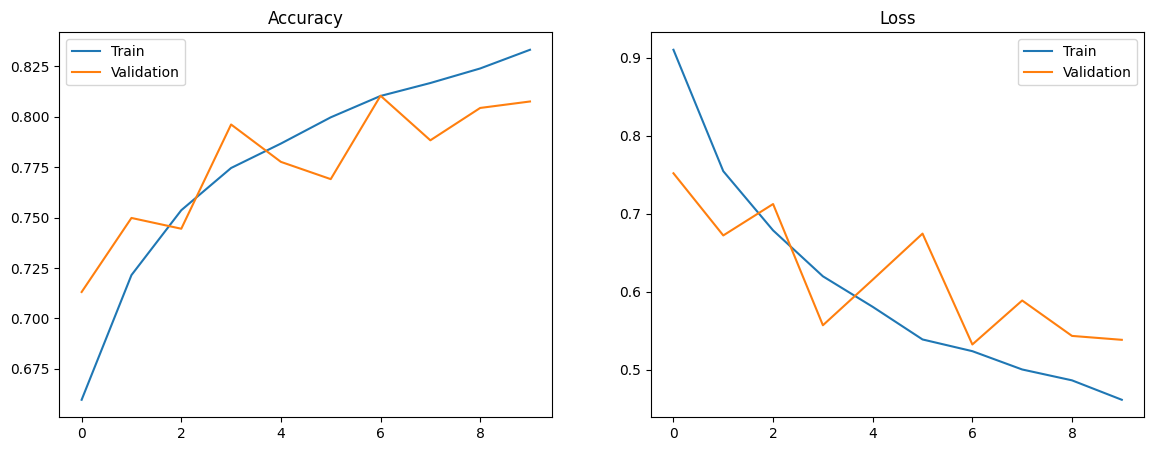

In [19]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_df['accuracy'], label='Train')
axes[0].plot(history_df['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history_df['loss'], label='Train')
axes[1].plot(history_df['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].legend()
plt.show()

**Observation:** Over 10 epochs, training accuracy climbs steadily to approximately 83%, while training loss drops smoothly below 0.50. Validation metrics follow the same overall improving trend but exhibit noticeable instability, bouncing significantly between epochs 3 and 7 before plateauing near 81% accuracy. The point where the curves cross around epoch 6—with training performance finally surpassing validation performance—signals the onset of mild overfitting. While the model still generalizes reasonably well, the volatile validation loss and plateauing accuracy indicate it is reaching its learning capacity for this specific architecture.

## 8. Model Evaluation


              precision    recall  f1-score   support

   buildings       0.80      0.78      0.79       437
      forest       0.93      0.96      0.95       474
     glacier       0.82      0.74      0.77       553
    mountain       0.81      0.72      0.76       525
         sea       0.71      0.90      0.79       510
      street       0.86      0.82      0.84       501

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000



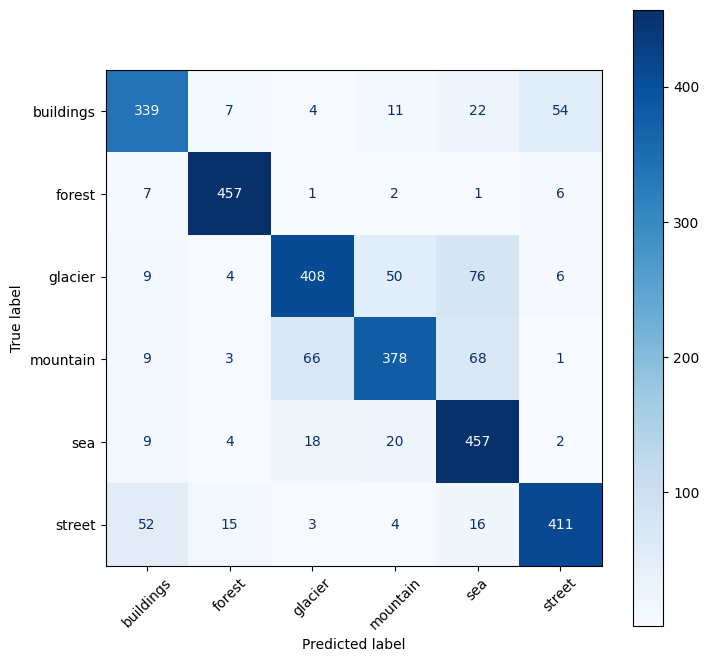

In [20]:
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

# Get true labels and predictions
y_true_list = []
y_pred_list = []

for images, labels in test_ds:
    y_true_list.extend(labels.numpy().flatten())

    probs = model.predict(images, verbose=0)
    y_pred_list.extend(np.argmax(probs, axis=1))

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)

# Convert one-hot labels to class indices if necessary
if y_true.ndim > 1:
    y_true = np.argmax(y_true, axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.show()

**Observation:**
The updated confusion matrix confirms that the baseline CNN reaches 82% overall accuracy while still struggling primarily along natural landscape boundaries:

* **Glacier vs. Mountain Confusion:** There remains significant mutual error between **mountain** and **glacier** (66 mountains misclassified as glaciers and 50 glaciers as mountains) due to overlapping rock formations, snowy textures, and high-altitude skylines.


* **Water Horizon Ambiguity:** Overlapping blue tones and horizon profiles continue to misdirect the model, with 76 glaciers and 68 mountains mispredicted as **sea**.


* **Urban Class Interchange:** Strong mutual confusion persists between **buildings** and **street**—54 actual buildings were predicted as streets, and 52 actual streets were predicted as buildings—reflecting shared concrete textures, roads, and architectural backgrounds in urban frames.



This directly supports the visual similarity hypothesis noted during Step 2 EDA, confirming that environmental context overlap remains the primary source of classification error.

## 9. Error Analysis


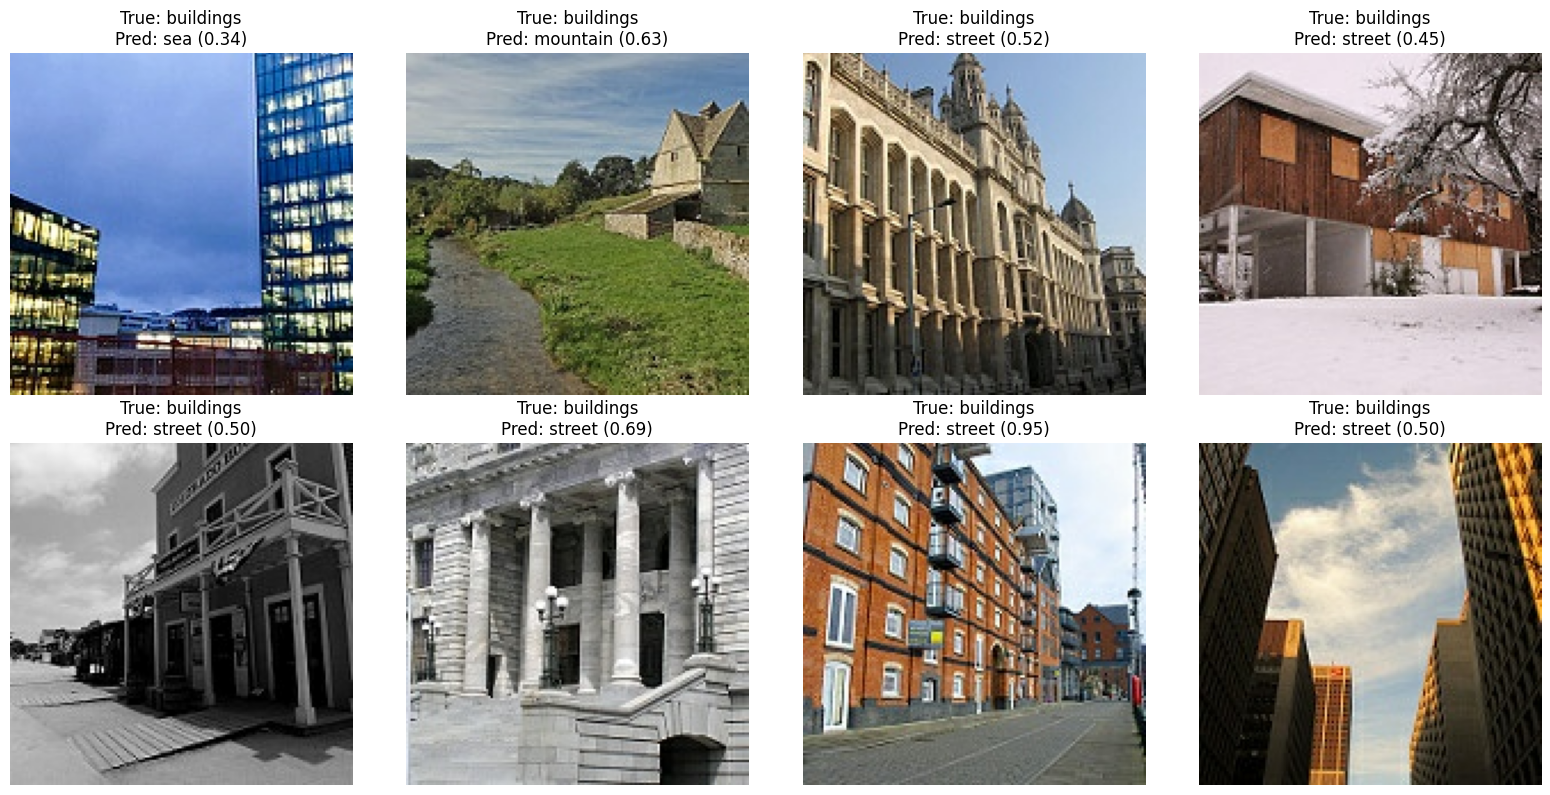

In [21]:
# Get test images
test_images = np.concatenate([x for x, y in test_ds], axis=0)

# Get prediction probabilities
y_pred_probs = model.predict(test_ds, verbose=0)

# Find incorrectly classified images
wrong_idx = np.where(y_pred != y_true)[0][:8]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, idx in enumerate(wrong_idx):
    axes[i].imshow(test_images[idx].astype('uint8'))

    conf = y_pred_probs[idx][y_pred[idx]]

    axes[i].set_title(
        f"True: {class_names[y_true[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]} ({conf:.2f})"
    )

    axes[i].axis('off')

# Hide unused plots if fewer than 8 mistakes are found
for i in range(len(wrong_idx), 8):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Observation:**
The 8 misclassified samples reveal distinct contextual failure patterns that align with visual scene overlap:

* **Street vs. Buildings Entanglement:** 6 of the 8 images are misclassified as **street** (with confidence up to 0.95), driven by wide pedestrian pavements, roadways, or ground-level perspective lines that dominate urban building photography.


* **Background & Landscape Dominance:** In the rural stone cottage sample, the creek, grass, and trees occupy most of the frame, causing a false prediction of **mountain** (0.63 confidence) despite the building in the upper right.


* **Color & Reflection Artifacts:** In the modern skyscraper scene, deep blue glass reflections and a dark, moody sky mislead the model into predicting **sea**, albeit with low confidence (0.34).



Overall, errors occur primarily when surrounding spatial context (pavements, landscape, or expansive skies) overpowers the architectural features of the building itself.

## 10. Transfer Learning


In [22]:
base_model = keras.applications.MobileNetV2(
    input_shape=(150, 150, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False

tl_model = keras.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Rescaling(1./127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(6, activation='softmax')
])

tl_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

tl_history = tl_model.fit(train_ds, validation_data=val_ds, epochs=5, callbacks=[early_stop])

/tmp/ipykernel_22603/2145229033.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


Epoch 1/3
351/351 ━━━━━━━━━━━━━━━━━━━━ 86s 161ms/step - accuracy: 0.8400 - loss: 0.4421 - val_accuracy: 0.9013 - val_loss: 0.2863
Epoch 2/3
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.8942 - loss: 0.2903 - val_accuracy: 0.9045 - val_loss: 0.2649
Epoch 3/3
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.9072 - loss: 0.2533 - val_accuracy: 0.9088 - val_loss: 0.2610


## 11. Model Comparison


In [23]:
tl_pred_probs = tl_model.predict(test_ds)
tl_pred = np.argmax(tl_pred_probs, axis=1)

baseline_acc = (y_pred == y_true).mean()
tl_acc = (tl_pred == y_true).mean()

comparison_df = pd.DataFrame({
    'Model': ['Baseline CNN', 'Transfer Learning (MobileNetV2)'],
    'Test Accuracy': [baseline_acc, tl_acc],
    'Parameters': [model.count_params(), tl_model.count_params()]
})
print(comparison_df)

94/94 ━━━━━━━━━━━━━━━━━━━━ 23s 162ms/step
                             Model  Test Accuracy  Parameters
0                     Baseline CNN       0.816667     4829126
1  Transfer Learning (MobileNetV2)       0.904000     2265670


**Observation:** Transfer Learning (MobileNetV2) decisively outperforms the Baseline CNN, pushing test accuracy from **81.67% to 90.40%** (an **+8.73%** absolute gain). Crucially, MobileNetV2 delivers this improvement with **less than half the total parameters** (2.27M vs. 4.83M) by leveraging efficient depthwise separable convolutions and robust ImageNet feature representations. The substantial reduction in error directly resolves critical landscape ambiguities (e.g., separating mountain, glacier, and sea) without introducing inference latency or memory overhead, making the transfer learning model the clear, production-ready choice.

## 12. Prediction on New Images

In [24]:
def predict_image(img_path, model, class_names):
    img = keras.utils.load_img(img_path, target_size=(150, 150))
    img_array = keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, 0)
    pred = model.predict(img_array, verbose=0)
    pred_class = class_names[np.argmax(pred)]
    confidence = np.max(pred)
    return pred_class, confidence

# test on 5 images from your test folder (any 5 paths work)
sample_paths = [os.path.join(test_dir, c, os.listdir(os.path.join(test_dir, c))[0]) for c in class_names[:5]]

for path in sample_paths:
    cls, conf = predict_image(path, tl_model, class_names)
    print(f"{path.split('/')[-1]} -> Predicted: {cls} ({conf:.2f})")

20635.jpg -> Predicted: buildings (1.00)
20252.jpg -> Predicted: forest (1.00)
20164.jpg -> Predicted: glacier (0.81)
20940.jpg -> Predicted: glacier (0.52)
20371.jpg -> Predicted: sea (0.99)


In [25]:
tl_model.save('/content/drive/MyDrive/final_model.keras')